# Lynceus Fraud Detection System

# Model Training

This notebook trains multiple machine learning models for fraud detection.

Workflow

- Load raw datasets
- Load preprocessing pipeline
- Transform datasets
- Handle class imbalance
- Train multiple models
- Compare performance
- Save the best model

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score,

    confusion_matrix,

    classification_report

)

In [3]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

In [4]:
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [5]:
from imblearn.over_sampling import SMOTE

# Paths

In [6]:
DATA_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/data/synthetic")

ARTIFACT_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts")

TRAIN_PATH = DATA_DIR / "transactions_train.csv"

VAL_PATH = DATA_DIR / "transactions_val.csv"

TEST_PATH = DATA_DIR / "transactions_test.csv"

PIPELINE_PATH = ARTIFACT_DIR / "preprocessing_pipeline.joblib"

# Load Raw Data

In [7]:
train_df = pd.read_csv(
    TRAIN_PATH,
    parse_dates=["timestamp"]
)

val_df = pd.read_csv(
    VAL_PATH,
    parse_dates=["timestamp"]
)

test_df = pd.read_csv(
    TEST_PATH,
    parse_dates=["timestamp"]
)

In [8]:
print(train_df.shape)

print(val_df.shape)

print(test_df.shape)

(70000, 23)
(15000, 23)
(15000, 23)


# Separate Features & Target

In [9]:
TARGET = "fraud_label"

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=TARGET)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

In [10]:
for df in [X_train, X_val, X_test]:

    df.drop(
        columns="timestamp",
        inplace=True
    )

# Fix Boolean Columns

In [11]:
binary_features = [

    "is_weekend",

    "is_new_receiver",

    "device_trusted",

    "cross_border",

    "high_risk_country"

]

for df in [X_train, X_val, X_test]:

    df[binary_features] = df[binary_features].astype("int8")

# Load Preprocessing Pipeline

In [12]:
preprocessor = joblib.load(
    PIPELINE_PATH
)

print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


# Transform Features

In [13]:
X_train = preprocessor.transform(X_train)

X_val = preprocessor.transform(X_val)

X_test = preprocessor.transform(X_test)

In [14]:
feature_names = preprocessor.get_feature_names_out()

In [15]:
X_train = pd.DataFrame(

    X_train,

    columns=feature_names

)

X_val = pd.DataFrame(

    X_val,

    columns=feature_names

)

X_test = pd.DataFrame(

    X_test,

    columns=feature_names

)

In [16]:
print(X_train.shape)

print(X_val.shape)

print(X_test.shape)

(70000, 41)
(15000, 41)
(15000, 41)


In [17]:
display(X_train.head())

,numeric__amount,numeric__hour,numeric__day_of_week,numeric__sender_account_age_days,numeric__receiver_account_age_days,numeric__sender_txn_count_24h,numeric__receiver_txn_count_24h,numeric__sender_avg_amount_30d,numeric__receiver_avg_amount_30d,numeric__velocity_score,...,categorical__merchant_category_TRAVEL,categorical__merchant_category_UTILITIES,categorical__device_type_ANDROID,categorical__device_type_IOS,categorical__device_type_LINUX,categorical__device_type_MACOS,categorical__device_type_WEB,categorical__device_type_WINDOWS,country__origin_country,country__destination_country
0,-0.566028,-2.396989,-0.483571,-1.162605,-0.450129,-0.426549,-1.205860,-0.675866,-0.614013,-0.573603,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0
1,-0.565130,-2.396989,-0.483571,-0.226140,1.666232,-0.600652,-1.540238,-0.689212,-0.818113,-0.743943,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0
2,-0.588907,-2.396989,-0.483571,-0.341472,-0.469019,-0.774755,-1.540238,-0.685421,1.825477,-0.941179,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,4.0
3,-0.531249,-2.396989,-0.483571,-0.176596,-0.294286,-0.426549,-1.289455,-0.642535,0.027128,-0.282233,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0
4,-0.609898,-2.396989,-0.483571,-1.318547,-1.028974,0.008709,-0.035536,-0.685069,-0.341204,0.067412,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Class Distribution Before SMOTE

In [18]:
print(y_train.value_counts())

fraud_label
0    68431
1     1569
Name: count, dtype: int64


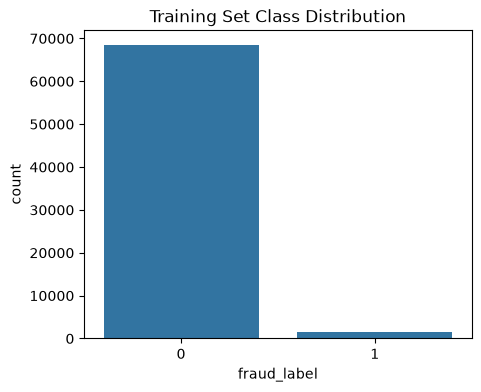

In [19]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Training Set Class Distribution")

plt.show()

# Handle Class Imbalance

SMOTE is applied only to the training data.

Validation and test datasets remain untouched to simulate real-world data.

In [20]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [21]:
print("Original Training Shape")

print(X_train.shape)
print(y_train.shape)

print()

print("After SMOTE")

print(X_train_smote.shape)
print(y_train_smote.shape)

Original Training Shape
(70000, 41)
(70000,)

After SMOTE
(136862, 41)
(136862,)


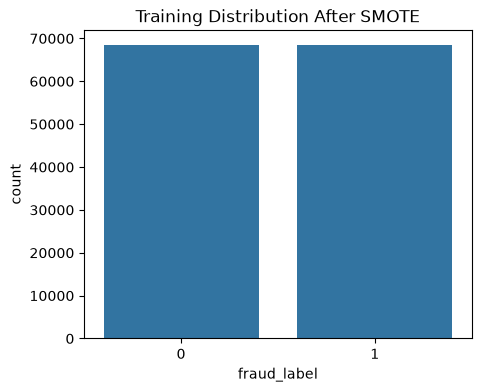

In [22]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train_smote)

plt.title("Training Distribution After SMOTE")

plt.show()

# Logistic Regression

In [23]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [24]:
print("Logistic Regression trained.")

Logistic Regression trained.


# Random Forest

In [25]:
random_forest = RandomForestClassifier(

    n_estimators=300,

    max_depth=15,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)

random_forest.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [26]:
print("Random Forest trained.")

Random Forest trained.


# XGBoost

In [27]:
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
print("XGBoost trained.")

XGBoost trained.


# LightGBM

In [29]:
lgbm_model = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=31,

    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Info] Number of positive: 68431, number of negative: 68431
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10455
[LightGBM] [Info] Number of data points in the train set: 136862, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [30]:
print("LightGBM trained.")

LightGBM trained.


# CatBoost

In [31]:
catboost_model = CatBoostClassifier(

    iterations=300,

    learning_rate=0.05,

    depth=6,

    loss_function="Logloss",

    verbose=False,

    random_seed=42
)

catboost_model.fit(
    X_train_smote,
    y_train_smote
)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [32]:
print("CatBoost trained.")

CatBoost trained.


# Store Models

In [33]:
models = {

    "Logistic Regression": logistic_model,

    "Random Forest": random_forest,

    "XGBoost": xgb_model,

    "LightGBM": lgbm_model,

    "CatBoost": catboost_model

}

In [34]:
print("Models trained:")

for model_name in models:
    print(f"• {model_name}")

Models trained:
• Logistic Regression
• Random Forest
• XGBoost
• LightGBM
• CatBoost


All models have now been trained.

The next step is to evaluate each model on the untouched validation set using multiple fraud-detection metrics.

# Model Evaluation

Each trained model is evaluated on the validation dataset.

Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Average Precision (PR-AUC)

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [36]:
results = []

In [37]:
for model_name, model in models.items():

    y_pred = model.predict(X_val)

    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_val, y_pred),

        "Precision": precision_score(y_val, y_pred),

        "Recall": recall_score(y_val, y_pred),

        "F1": f1_score(y_val, y_pred),

        "ROC_AUC": roc_auc_score(y_val, y_prob),

        "PR_AUC": average_precision_score(y_val, y_prob)

    })

In [38]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.825467,0.091658,0.759644,0.163578,0.851318,0.284737
1,Random Forest,0.982133,0.629213,0.498516,0.556291,0.879047,0.523539
2,XGBoost,0.984000,0.727700,0.459941,0.563636,0.880417,0.560934
3,LightGBM,0.984467,0.734234,0.483680,0.583184,0.883758,0.583684
4,CatBoost,0.984400,0.797688,0.409496,0.541176,0.880930,0.582227


In [39]:
results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.984467,0.734234,0.483680,0.583184,0.883758,0.583684
1,CatBoost,0.984400,0.797688,0.409496,0.541176,0.880930,0.582227
2,XGBoost,0.984000,0.727700,0.459941,0.563636,0.880417,0.560934
3,Random Forest,0.982133,0.629213,0.498516,0.556291,0.879047,0.523539
4,Logistic Regression,0.825467,0.091658,0.759644,0.163578,0.851318,0.284737


# Best Validation Model

In [40]:
best_model_name = results_df.loc[0, "Model"]

best_model = models[best_model_name]

print("Best Model :", best_model_name)

Best Model : LightGBM


# Visualization

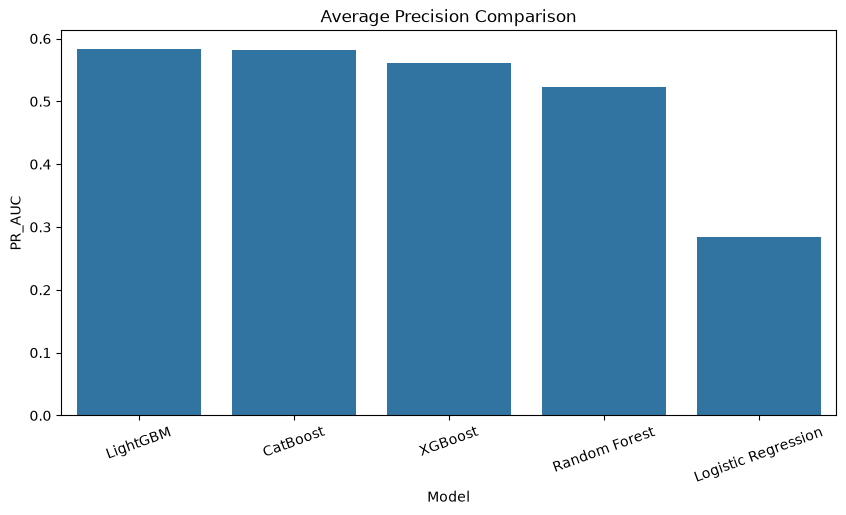

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="PR_AUC"
)

plt.xticks(rotation=20)

plt.title("Average Precision Comparison")

plt.show()

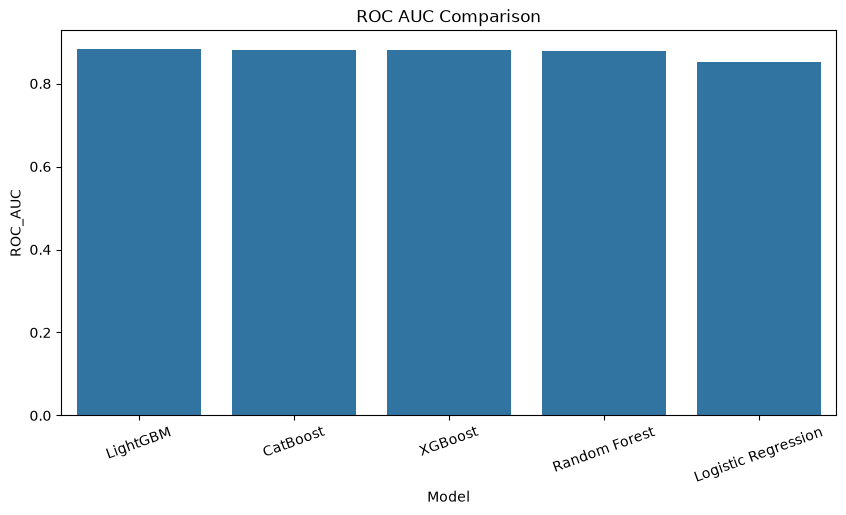

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC_AUC"
)

plt.xticks(rotation=20)

plt.title("ROC AUC Comparison")

plt.show()

# Detailed Classification Report

In [43]:
from sklearn.metrics import classification_report

In [44]:
y_pred = best_model.predict(X_val)

print(

    classification_report(

        y_val,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14663
           1       0.73      0.48      0.58       337

    accuracy                           0.98     15000
   macro avg       0.86      0.74      0.79     15000
weighted avg       0.98      0.98      0.98     15000



# Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
cm = confusion_matrix(
    y_val,
    y_pred
)

cm

array([[14604,    59],
       [  174,   163]])

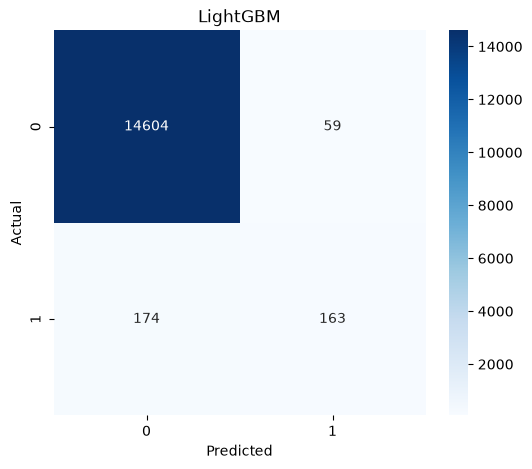

In [47]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(best_model_name)

plt.show()

# ROC Curve

In [48]:
from sklearn.metrics import RocCurveDisplay

<Figure size 600x600 with 0 Axes>

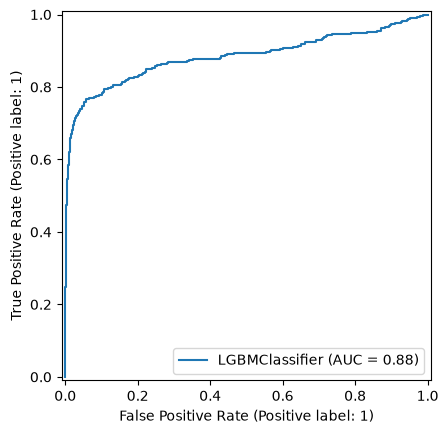

In [49]:
plt.figure(figsize=(6,6))

RocCurveDisplay.from_estimator(

    best_model,

    X_val,

    y_val

)

plt.show()

# Precision-Recall Curve

In [50]:
from sklearn.metrics import PrecisionRecallDisplay

<Figure size 600x600 with 0 Axes>

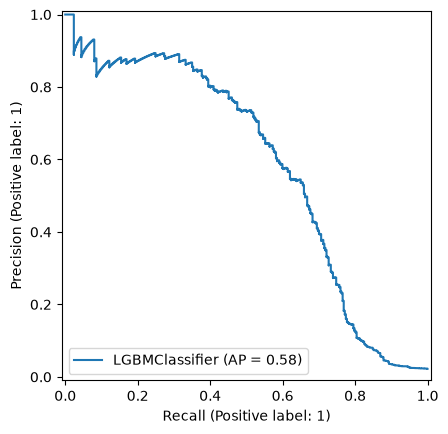

In [51]:
plt.figure(figsize=(6,6))

PrecisionRecallDisplay.from_estimator(

    best_model,

    X_val,

    y_val

)

plt.show()

# Evaluation Summary

The model with the highest PR-AUC on the validation set will be exported for production inference.

In [53]:
import joblib
from pathlib import Path

ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    ARTIFACT_DIR / "best_model.joblib"
)

print("Best model saved successfully.")

Best model saved successfully.


In [54]:
import json

metadata = {
    "model_name": best_model_name,
    "feature_names": list(feature_names),
    "binary_features": binary_features,
    "threshold": 0.50,   # placeholder, updated after evaluation
    "target": TARGET
}

with open(
    ARTIFACT_DIR / "model_metadata.json",
    "w"
) as f:
    json.dump(metadata, f, indent=4)